In [50]:
import pandas as pd
import json
from pathlib import Path
from elasticsearch import Elasticsearch, helpers
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import Markdown, display
import subprocess
import shutil

In [51]:
BASE_DIR       = Path.cwd()
DATA_DIR       = BASE_DIR

CSV_PATH       = DATA_DIR / "documents.csv"
JSONL_PATH     = DATA_DIR / "documents.jsonl"
QUERIES_PATH   = DATA_DIR / "queries.csv"
QRELS_CSV_PATH = DATA_DIR / "qrels.csv"   # αρχικό csv από την εκφώνηση
QRELS_TXT_PATH = DATA_DIR / "qrels.txt"   # TREC qrels: qid Q0 docid rel

In [52]:
# Load CSV File
try:
    df = pd.read_csv(CSV_PATH, encoding="utf-8")
except FileNotFoundError:
    raise SystemExit(f"File not found: {CSV_PATH}")
except Exception as e:
    raise SystemExit(f"Error reading CSV: {e}")

In [53]:
# Display Columns and Document Count
print(f"CSV loaded successfully → {len(df)} documents found")
print(f"Columns detected: {list(df.columns)}")

CSV loaded successfully → 18316 documents found
Columns detected: ['ID', 'Text']


In [54]:
# Validate Required Columns
required_cols = {"ID", "Text"}
missing = required_cols - set(df.columns)
if missing:
    raise SystemExit(f"Missing expected columns: {missing}")

In [55]:
def preprocess(s):
    if not isinstance(s, str):
        return ""
    s = s.strip()
    s = re.sub(r"\s+", " ", s)                       # collapse spaces/newlines
    s = re.sub(r"http\S+|www\.\S+", "<URL>", s)      # replace URLs
    s = re.sub(r"\S+@\S+", "<EMAIL>", s)             # replace emails
    s = re.sub(r"<[^>]+>", " ", s)                   # remove HTML tags
    s = ''.join(ch for ch in s if ord(ch) >= 32)     # remove control chars
    s = re.sub(r"['\"]", "", s)                      # remove single and double quotes
    return s.strip()


df = df.dropna(subset=["Text"])
df["Text"] = df["Text"].astype(str).map(preprocess)

In [56]:
# Convert to JSONL
records_written = 0
with open(JSONL_PATH, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        record = {
            "id": row["ID"],     
            "text": row["Text"]
        }
        json_line = json.dumps(record, ensure_ascii=False)
        f.write(json_line + "\n")
        records_written += 1

print(f"Converted {records_written} rows → JSONL format")
print(f"Output saved at: {JSONL_PATH.resolve()}")

Converted 18316 rows → JSONL format
Output saved at: C:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\documents.jsonl


In [57]:
class Search:
    def __init__(self):
        self.es = Elasticsearch("http://127.0.0.1:9200")
        client_info = self.es.info()
        print('Connected to Elasticsearch!')
        pprint(client_info.body)

    #Return instance
    def get_es(self):
        return self.es

    #Creates empty index with the parameters we feed
    def create_index(self):
        index_settings = {
            "settings": {
                "similarity": {
                    "default": {"type": "BM25"}
                },
                "analysis": {
                    "analyzer": {
                        "my_english_analyzer": {
                            "type": "custom",
                            "tokenizer": "standard",
                            "filter": [
                                "lowercase",
                                "english_stop",
                                "porter_stem"
                            ]
                        }
                    },
                    "filter": {
                        "english_stop": {
                            "type": "stop",
                            "stopwords": "_english_"
                        }
                    }
                }
            },
            "mappings": {
                "properties": {
                    "id": {"type": "keyword"},
                    "text": {"type": "text", "analyzer": "my_english_analyzer"}
                }
            }
        }

        self.es.indices.create(index='ir2025', body=index_settings)
        print("Index created with English analyzer and BM25 similarity.")

    #Insert single document
    def insert_document(self, document):
        return self.es.index(index='ir2025', document=document)

    #Insert multiple indexes
    def insert_documents(self, documents):
        operations = []
        for document in documents:
            operations.append({'index': {'_index': 'ir2025'}})
            operations.append(document)

        result = self.es.bulk(operations=operations)
        print("Insertion finished.")
        print(result)

    #Deletes index
    def delete_index(self, index_name="ir2025"):
        if self.es.indices.exists(index=index_name):
            self.es.indices.delete(index=index_name)
            print(f"Index '{index_name}' deleted successfully.")
        else:
            print(f"Index '{index_name}' does not exist.")

    #Check if index exists
    def exists(self, index_name="ir2025"):
        try:
            return self.es.indices.exists(index=index_name)
        except Exception as e:
            print(f"Error checking if index exists: {e}")
            return False

    #Helper function for bulk indexing
    def generate_actions(self, jsonl_path, index_name):
        with open(jsonl_path, encoding="utf-8") as f:
            for i, line in enumerate(f):
                yield {
                    "_index": index_name,
                    "_id": i,
                    "_source": json.loads(line)
                }

    #Bulk index docs
    def index_documents(self, jsonl_path, index_name):
        actions = self.generate_actions(jsonl_path, index_name)
        success, _ = helpers.bulk(self.get_es(), actions)
        print(f"Successfully indexed {success} documents into '{index_name}'")

    #Runs query
    def search_query(self, query_text, k=10, index_name="ir2025"):
        try:
            resp = self.es.search(
                index=index_name,
                query={"match": {"text": {"query": query_text}}},
                size=k
            )
            return resp["hits"]["hits"]
        except Exception as e:
            print(f"Error executing search query: {e}")
            return []



In [58]:
class Evaluation:
    def __init__(
        self,
        search_client,
        data_dir: Path,
        qrels_csv_path: Path,
        qrels_txt_path: Path = None,
        trec_eval_bin: Path = None,
    ):
        self.search = search_client
        self.data_dir = Path(data_dir)
        self.qrels_csv_path = Path(qrels_csv_path)
        self.qrels_txt_path = Path(qrels_txt_path) if qrels_txt_path else self.data_dir / "qrels.txt"

        # Βεβαιώσου ότι υπάρχει qrels.txt σε TREC format
        self._ensure_trec_qrels()

        # Βρες το trec_eval.exe
        if trec_eval_bin is None:
            self.trec_eval_bin = self._find_trec_eval()
        else:
            self.trec_eval_bin = Path(trec_eval_bin)

        if not self.trec_eval_bin or not self.trec_eval_bin.exists():
            raise SystemExit(
                "trec_eval binary not found. Put trec_eval.exe στον φάκελο trec_eval "
                "ή δώσε σωστό path στον constructor."
            )

        if not self.qrels_txt_path.exists():
            raise SystemExit(f"qrels file not found: {self.qrels_txt_path}")

        print(f"Using trec_eval at: {self.trec_eval_bin}")
        print(f"Using qrels file:  {self.qrels_txt_path}")

    # ------------------------------------------------------------------
    # qrels.csv -> qrels.txt (TREC) (ιδιωτικές μέθοδοι)
    # ------------------------------------------------------------------
    def _fix_and_write_qrels(self):
        """Διαβάζει qrels.csv και γράφει qrels.txt σε μορφή: qid 0 docid rel."""
        if not self.qrels_csv_path.exists():
            raise SystemExit(f"qrels.csv not found: {self.qrels_csv_path}")

        dfq = pd.read_csv(
            self.qrels_csv_path,
            sep=None,
            engine="python",
            encoding="utf-8-sig",
        )
        dfq = dfq.dropna(how="all")
        dfq = dfq.astype(str).applymap(lambda x: x.strip())
        cols = list(dfq.columns)

        # optional: docids από ένα sample results αρχείο (αν υπάρχει)
        res_docids = set()
        sample_results_path = self.data_dir / "results_20.txt"
        if sample_results_path.exists():
            with open(sample_results_path, encoding="utf-8", errors="replace") as f:
                for ln in f:
                    parts = re.split(r"\s+", ln.strip())
                    if len(parts) >= 3:
                        res_docids.add(parts[2])

        candidates = []
        for c in cols:
            vals = dfq[c].dropna().astype(str).str.strip().unique()[:200].tolist()
            inter = len(set(vals) & res_docids) if res_docids else 0
            num_like = sum(1 for v in vals if re.match(r"^\d+$", v))
            candidates.append((c, inter, num_like, vals[:5]))

        docid_col = max(candidates, key=lambda x: (x[1], x[2]))[0]
        qid_col = cols[0]
        rel_col = None
        for c, inter, num_like, vals in candidates:
            if c in (qid_col, docid_col):
                continue
            sample_vals = dfq[c].dropna().astype(str).str.strip().unique()[:50].tolist()
            if sample_vals and all(re.match(r"^\d+$", v) for v in sample_vals):
                rel_col = c
                break
        if rel_col is None:
            others = [c for c in cols if c not in (qid_col, docid_col)]
            rel_col = others[-1] if others else cols[-1]

        with open(self.qrels_txt_path, "w", encoding="utf-8") as out:
            for _, row in dfq.iterrows():
                qid = str(row[qid_col]).strip()
                docid = str(row[docid_col]).strip()
                rel = str(row[rel_col]).strip()
                if not qid or not docid or docid.upper() == "Q0":
                    continue
                out.write(f"{qid} 0 {docid} {rel}\n")

        print(
            f"Wrote TREC qrels -> {self.qrels_txt_path} "
            f"(qid_col={qid_col}, docid_col={docid_col}, rel_col={rel_col})"
        )

    def _ensure_trec_qrels(self):
        """Χρησιμοποιεί υπάρχον qrels.txt ή το δημιουργεί από qrels.csv."""
        if self.qrels_txt_path.exists():
            print(f"Using existing TREC qrels: {self.qrels_txt_path}")
            return
        print("TREC qrels not found, creating from qrels.csv ...")
        self._fix_and_write_qrels()

    # ------------------------------------------------------------------
    # Εύρεση trec_eval.exe
    # ------------------------------------------------------------------
    def _find_trec_eval(self):
        candidates = [
            self.data_dir / "trec_eval" / "trec_eval.exe",
            self.data_dir / "trec_eval" / "trec_eval",
            self.data_dir / "trec_eval.exe",
            self.data_dir / "trec_eval",
        ]
        for p in candidates:
            if p.exists():
                return p

        p_on_path = shutil.which("trec_eval") or shutil.which("trec_eval.exe")
        if p_on_path:
            return Path(p_on_path)

        if self.data_dir.exists():
            for p in self.data_dir.rglob("trec_eval*"):
                if p.is_file():
                    return p
        return None

    # ------------------------------------------------------------------
    # Δημιουργία results_20/30/50.txt
    # ------------------------------------------------------------------
    def generate_file_results(self, queries_path: Path, ks=(20, 30, 50)):
        df_queries = pd.read_csv(queries_path, encoding="utf-8")
        print(f"Loaded queries: {len(df_queries)}")

        for k in ks:
            results_path = self.data_dir / f"results_{k}.txt"
            with open(results_path, "w", encoding="utf-8") as f:
                for _, row in df_queries.iterrows():
                    qid = str(row[0])
                    qtext = str(row[1])
                    results = self.search.search_query(qtext, k)
                    for rank, hit in enumerate(results, start=1):
                        docid = hit["_source"]["id"]
                        score = hit["_score"]
                        f.write(f"{qid} Q0 {docid} {rank} {score:.4f} BM25\n")
            print(f"Created results file: {results_path}")

    # ------------------------------------------------------------------
    # Τρέχει trec_eval για 1 αρχείο results_k
    # ------------------------------------------------------------------
    def _run_trec_eval_for_file(self, results_file: Path):
        if not results_file.exists():
            raise SystemExit(f"results file not found: {results_file}")

        cmd = [
            str(self.trec_eval_bin),
            str(self.qrels_txt_path),
            str(results_file),
            "-m", "all_trec",
        ]

        print("Running:", " ".join(cmd))
        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode != 0:
            print("--- trec_eval stderr ---")
            print(proc.stderr)
            raise SystemExit(f"trec_eval failed for {results_file} (rc={proc.returncode})")

        parsed = {}
        for line in proc.stdout.strip().splitlines():
            parts = re.split(r"\s+", line.strip())
            if len(parts) < 3:
                continue
            metric = parts[0]   # π.χ. map, P_5, P_10, ...
            target = parts[1]   # συνήθως 'all'
            value_str = parts[-1]

            if target.lower() != "all":
                continue

            # MAP
            if metric.lower().startswith("map") and metric.lower() == "map":
                try:
                    parsed["MAP"] = float(value_str)
                except ValueError:
                    pass
                continue

            # P@k: P_5, P_10, P_15, P_20, ...
            m = re.match(r"^P_(\d+)$", metric)
            if m:
                k = int(m.group(1))
                key = f"P@{k}"
                try:
                    parsed[key] = float(value_str)
                except ValueError:
                    pass
                continue

        # Επιστρέφουμε μόνο τα P@5,10,15,20 που μας νοιάζουν + MAP
        return {
            "P@5":  parsed.get("P@5"),
            "P@10": parsed.get("P@10"),
            "P@15": parsed.get("P@15"),
            "P@20": parsed.get("P@20"),
            "MAP":  parsed.get("MAP"),
        }

    # ------------------------------------------------------------------
    # Κύρια αξιολόγηση με trec_eval
    # ------------------------------------------------------------------
    def evaluate_with_trec_eval(self, ks=(20, 30, 50), out_summary_path: Path = None):
        summary_rows = []
        for k in ks:
            results_file = self.data_dir / f"results_{k}.txt"
            metrics = self._run_trec_eval_for_file(results_file)
            row = {"retrieval_k": k}
            row.update(metrics)
            summary_rows.append(row)

        df_trec = pd.DataFrame(summary_rows).sort_values("retrieval_k").reset_index(drop=True)

        print("\n--- trec_eval summary ---")
        print(df_trec.to_string(index=False))

        if out_summary_path is not None:
            with open(out_summary_path, "w", encoding="utf-8") as f:
                for _, r in df_trec.iterrows():
                    k = int(r["retrieval_k"])
                    f.write(f"# summary for results_{k}.txt\n")
                    for kk in [5, 10, 15, 20]:
                        val = r.get(f"P@{kk}")
                        if val is None:
                            f.write(f"P_{kk}\tall\tNaN\n")
                        else:
                            f.write(f"P_{kk}\tall\t{val:.4f}\n")
                    mapv = r.get("MAP")
                    if mapv is None:
                        f.write("map\tall\tNaN\n\n")
                    else:
                        f.write(f"map\tall\t{mapv:.4f}\n\n")
            print(f"Wrote trec_eval summary file: {out_summary_path}")

        return df_trec

In [59]:
#Initiate search class and index name
search=Search()
INDEX_NAME = "ir2025" 

Connected to Elasticsearch!
{'cluster_name': 'elasticsearch',
 'cluster_uuid': 'NfFciNgwSE648-kMzsJiVg',
 'name': 'SWKRATISLAPTOP',
 'tagline': 'You Know, for Search',
 'version': {'build_date': '2025-09-16T22:05:19.073893347Z',
             'build_flavor': 'default',
             'build_hash': '0b7fe68d2e369469ff9e9f344ab6df64ab9c5293',
             'build_snapshot': False,
             'build_type': 'zip',
             'lucene_version': '10.2.2',
             'minimum_index_compatibility_version': '8.0.0',
             'minimum_wire_compatibility_version': '8.19.0',
             'number': '9.1.4'}}


In [60]:
#Delete index if exists
if search.exists(INDEX_NAME):
    search.delete_index(index_name=INDEX_NAME)
    
#Create new empty index
search.create_index()

#Index docs
search.index_documents(JSONL_PATH,INDEX_NAME)

Index 'ir2025' deleted successfully.
Index created with English analyzer and BM25 similarity.
Successfully indexed 18316 documents into 'ir2025'


In [61]:
evaluator = Evaluation(
    search_client=search,
    data_dir=DATA_DIR,
    qrels_csv_path=DATA_DIR / "qrels.csv",   # ή ό,τι path έχεις
    qrels_txt_path=DATA_DIR / "qrels.txt",   # προαιρετικό, μπορείς και να το παραλείψεις
)

evaluator.generate_file_results(QUERIES_PATH, ks=(20, 30, 50))
df_trec = evaluator.evaluate_with_trec_eval(ks=(20, 30, 50), out_summary_path=DATA_DIR / "trec_eval_summary.txt")

Using existing TREC qrels: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\qrels.txt
Using trec_eval at: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\trec_eval\trec_eval.exe
Using qrels file:  c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\qrels.txt
Loaded queries: 10


C:\Users\swkra\AppData\Local\Temp\ipykernel_9860\2541594010.py:142: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qid = str(row[0])
C:\Users\swkra\AppData\Local\Temp\ipykernel_9860\2541594010.py:143: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qtext = str(row[1])


Created results file: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_20.txt
Created results file: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_30.txt
Created results file: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_50.txt
Running: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\trec_eval\trec_eval.exe c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\qrels.txt c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_20.txt -m all_trec
Running: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\trec_eval\trec_eval.exe c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\qrels.txt c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_30.txt -m all_trec
Running: c:\Users\swkra\OneDrive - aueb.gr\Uni\

In [64]:
#Visualize Results
def visualize_metrics(df):
    metrics_to_plot = ["P@5", "P@10", "P@15", "P@20", "MAP"]
    df_melted = df.melt(id_vars="retrieval_k", value_vars=metrics_to_plot,
                         var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(wspace=0.15) 

    sns.lineplot(
        data=df_melted,
        x="retrieval_k",
        y="Score",
        hue="Metric",
        marker='o',
        dashes=False,
        palette="deep",
        ax=ax1
    )

    ax1.set_title("Metric Trends Across Maximum Retrieval Depth ($k_{max}$)", fontsize=14, weight="bold")
    ax1.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax1.set_ylabel("Score", fontsize=12)
    ax1.set_ylim(df_melted["Score"].min() * 0.9, 1.05)
    ax1.legend(title="Metric", loc="upper right")
    ax1.grid(axis='y')

    map_data = df_melted[df_melted["Metric"] == "MAP"]
    for x, y in zip(map_data["retrieval_k"], map_data["Score"]):
        ax1.text(x + 1, y, f'{y:.4f}', color='red', ha='left', va='center', fontsize=10)


    map_only_data = map_data

    sns.barplot(
        data=map_only_data,
        x="retrieval_k",
        y="Score",
        palette=sns.color_palette("Reds_d", n_colors=len(map_only_data)),
        ax=ax2
    )

    ax2.set_title("Mean Average Precision (MAP) by $k_{max}$", fontsize=14, weight="bold")
    ax2.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax2.set_ylabel("", fontsize=12)
    ax2.set_ylim(df_melted["Score"].min() * 0.9, 1.05) 

    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.4f", label_type="center", fontsize=12, color='white', weight='bold')

    plt.tight_layout()
    plt.show()

C:\Users\swkra\AppData\Local\Temp\ipykernel_9860\185586646.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


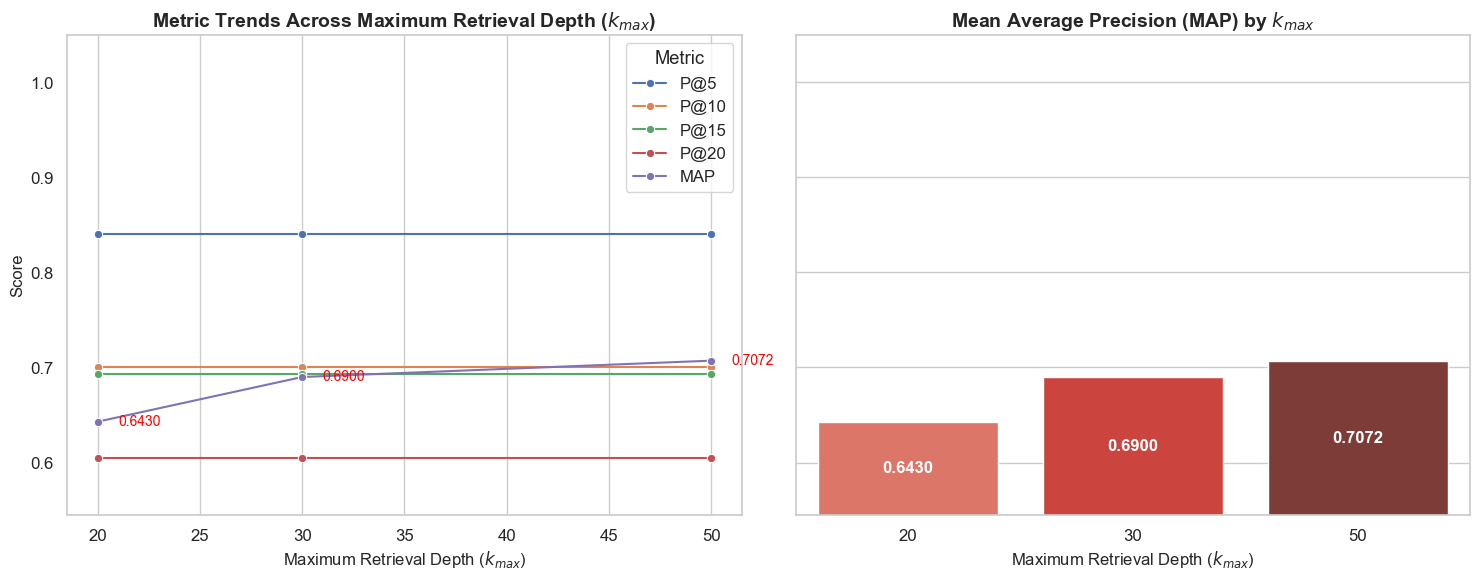

In [65]:
visualize_metrics(df_trec)